In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [2]:
# ====================================
# 1. Variables
# ====================================
heart_rate = ctrl.Antecedent(np.arange(40, 161, 1), 'heart_rate')
blood_pressure = ctrl.Antecedent(np.arange(80, 201, 1), 'blood_pressure')
risk = ctrl.Consequent(np.arange(0, 101, 1), 'risk')

In [5]:
# ====================================
# 2. Membership Functions
# ====================================
# Heart Rate (Trapezoidal)
heart_rate['low'] = fuzz.gaussmf(heart_rate.universe, 55, 8)
heart_rate['medium'] = fuzz.trapmf(heart_rate.universe, [60, 70, 90, 100])
heart_rate['high'] = fuzz.gaussmf(heart_rate.universe, 110, 12)

blood_pressure['normal'] = fuzz.gaussmf(blood_pressure.universe, 117, 10)     # نرمال: 107-127
blood_pressure['elevated'] = fuzz.gaussmf(blood_pressure.universe, 135, 8)    # بالا خفیف: 127-143
blood_pressure['high'] = fuzz.trapmf(blood_pressure.universe, [140, 155, 200, 200]) # 

risk['low'] = fuzz.trapmf(risk.universe, [0, 0, 25, 45])  # ناحیه Low: 0-25% قطعی، 25-45% انتقال
risk['medium'] = fuzz.trapmf(risk.universe,[30, 45, 55, 70])  # ناحیه Medium: 45-55% قطعی
risk['high'] = fuzz.trapmf(risk.universe, [55, 75, 100, 100])  # ناحیه High: 75-100% قطعی

D:\Shahed\AI Intro\a\.venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


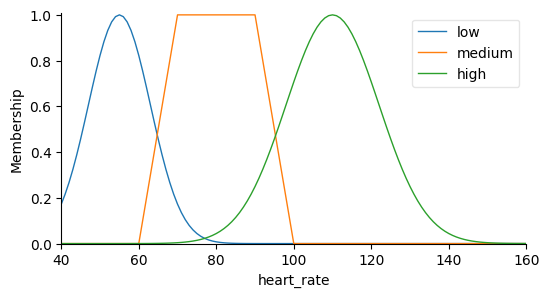

In [7]:
heart_rate.view()
fig = plt.gcf()
fig.set_size_inches(6, 3)
plt.show()

D:\Shahed\AI Intro\a\.venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


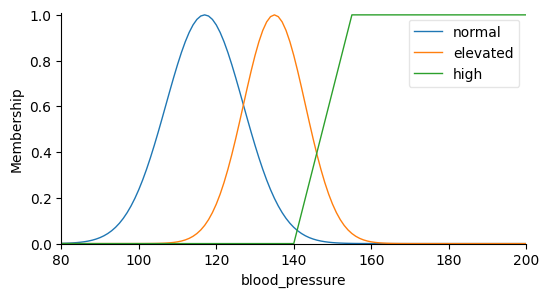

In [8]:
blood_pressure.view()
fig = plt.gcf()
fig.set_size_inches(6, 3)
plt.show()

D:\Shahed\AI Intro\a\.venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


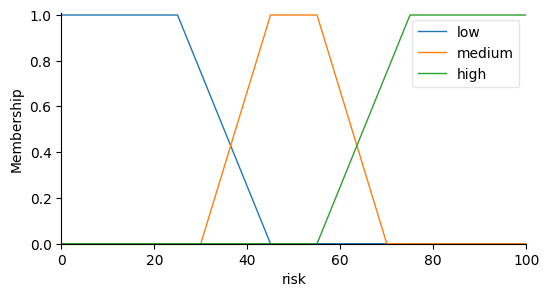

In [9]:
risk.view()
fig = plt.gcf()
fig.set_size_inches(6, 3)
plt.show()

In [11]:
rule1 = ctrl.Rule(heart_rate['low'] & blood_pressure['normal'], risk['low'])
rule2 = ctrl.Rule(heart_rate['medium'] & blood_pressure['elevated'], risk['medium'])
rule3 = ctrl.Rule(heart_rate['high'] | blood_pressure['high'], risk['high'])

# ====================================
# 4. Build System
# ====================================
risk_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
risk_sim = ctrl.ControlSystemSimulation(risk_ctrl)

In [12]:
hr_value = 90
bp_value = 120

In [14]:
risk_sim.input['heart_rate'] = hr_value
risk_sim.input['blood_pressure'] = bp_value

risk_sim.compute()

In [16]:
risk_sim.output['risk']

np.float64(68.55462489647608)